# ConsultBae Assignment — Task 1: Merge Pipeline

## Step 1: Create the MySQL Database

In [1]:
import pandas as pd
from sqlalchemy import create_engine, text


DB_USER = "root"
DB_PASSWORD = "root123"
DB_HOST = "localhost"
DB_PORT = 3306
DB_NAME = "consultbae"


In [2]:
engine_no_db = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/")

with engine_no_db.connect() as conn:
    conn.execute(text(f"CREATE DATABASE IF NOT EXISTS {DB_NAME}"))
    conn.commit()

print(f"Database '{DB_NAME}' ready hai")


Database 'consultbae' ready hai


## Step 2: Connect to the `consultbae` Database



In [3]:
engine = create_engine(f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

with engine.connect() as conn:
    print("Connected to:", conn.execute(text("SELECT DATABASE()")).scalar())


Connected to: consultbae


## Step 3: Load the 3 Raw CSVs into Staging Tables



In [4]:
import sys
!{sys.executable} -m pip install --upgrade "sqlalchemy>=2.0.36"


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
raw_naukri = pd.read_csv(r"C:\Users\admin\Desktop\Assignment of ConsultBae\source1_naukri_applicants.csv")
raw_gig = pd.read_csv(r"C:\Users\admin\Desktop\Assignment of ConsultBae\source2_gig_workers.csv")
raw_cbnexus = pd.read_csv(r"C:\Users\admin\Desktop\Assignment of ConsultBae\source3_cbnexus_contacts.csv")

DB_URI = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

raw_naukri.to_sql("raw_naukri", DB_URI, if_exists="replace", index=False)
raw_gig.to_sql("raw_gig", DB_URI, if_exists="replace", index=False)
raw_cbnexus.to_sql("raw_cbnexus", DB_URI, if_exists="replace", index=False)

print("raw_naukri  :", len(raw_naukri), "rows loaded")
print("raw_gig     :", len(raw_gig), "rows loaded")
print("raw_cbnexus :", len(raw_cbnexus), "rows loaded")


raw_naukri  : 42 rows loaded
raw_gig     : 32 rows loaded
raw_cbnexus : 31 rows loaded


In [6]:
raw_naukri.head(5)

,Full Name,Email,Phone,City,Experience (Years),Current CTC,Applied Date,Skills
0,Tanvi Gupta,tanvi.gupta31@example.com,919000000254,Bengaluru,4.2,417964.0,24-07-2026,"n8n, LangChain, REST APIs, MongoDB, SQL"
1,Manish Reddy,manish.reddy73@example.com,9000000237,GURGAON,3.5,332456.0,2026-08-08,"Docker, Zapier, JavaScript"
2,Priya Singh,priya.singh61@mailtest.example.org,9000000287,GURGAON,3.0,775670.0,01-08-2026,"React, Zapier, n8n, MySQL, Python, SQL"
3,Vikram Saxena,vikram.saxena60@example.com,9000000113,GURGAON,1.9,654699.0,7 Jul 2026,"Selenium, Web Scraping, React, Docker, SQL, Fa..."
4,Amit Agarwal,amit.agarwal3@mailtest.example.org,919000000288,pune,1.8,4.2,19-07-2026,"SQL, Python, JavaScript, Docker"


In [7]:
raw_naukri.head(5)

,Full Name,Email,Phone,City,Experience (Years),Current CTC,Applied Date,Skills
0,Tanvi Gupta,tanvi.gupta31@example.com,919000000254,Bengaluru,4.2,417964.0,24-07-2026,"n8n, LangChain, REST APIs, MongoDB, SQL"
1,Manish Reddy,manish.reddy73@example.com,9000000237,GURGAON,3.5,332456.0,2026-08-08,"Docker, Zapier, JavaScript"
2,Priya Singh,priya.singh61@mailtest.example.org,9000000287,GURGAON,3.0,775670.0,01-08-2026,"React, Zapier, n8n, MySQL, Python, SQL"
3,Vikram Saxena,vikram.saxena60@example.com,9000000113,GURGAON,1.9,654699.0,7 Jul 2026,"Selenium, Web Scraping, React, Docker, SQL, Fa..."
4,Amit Agarwal,amit.agarwal3@mailtest.example.org,919000000288,pune,1.8,4.2,19-07-2026,"SQL, Python, JavaScript, Docker"


In [8]:
raw_cbnexus.head(5)

,Name,Phone Number,City,Verified,Projects Completed
0,Rohit Nair,9000000268,Gurgaon,Y,13
1,RITU SHARMA,9000000146,Noida,yes,15
2,Priya Saxena,919000000231,New Delhi,No,12
3,Arjun Mehta,+91-9000000131,Noida,No,9
4,Nikhil Mehta,+91-9000000104,pune,Y,10


## Step 4: Verify — Tables is created in mysql

In [9]:
with engine.connect() as conn:
    tables = conn.execute(text("SHOW TABLES")).fetchall()
    print("Tables in DB:", [t[0] for t in tables])

raw_naukri.head()


Tables in DB: ['people_master', 'raw_cbnexus', 'raw_gig', 'raw_naukri']


,Full Name,Email,Phone,City,Experience (Years),Current CTC,Applied Date,Skills
0,Tanvi Gupta,tanvi.gupta31@example.com,919000000254,Bengaluru,4.2,417964.0,24-07-2026,"n8n, LangChain, REST APIs, MongoDB, SQL"
1,Manish Reddy,manish.reddy73@example.com,9000000237,GURGAON,3.5,332456.0,2026-08-08,"Docker, Zapier, JavaScript"
2,Priya Singh,priya.singh61@mailtest.example.org,9000000287,GURGAON,3.0,775670.0,01-08-2026,"React, Zapier, n8n, MySQL, Python, SQL"
3,Vikram Saxena,vikram.saxena60@example.com,9000000113,GURGAON,1.9,654699.0,7 Jul 2026,"Selenium, Web Scraping, React, Docker, SQL, Fa..."
4,Amit Agarwal,amit.agarwal3@mailtest.example.org,919000000288,pune,1.8,4.2,19-07-2026,"SQL, Python, JavaScript, Docker"


## step-5 Read Raw Tables Back from MySQL

In [10]:
naukri = pd.read_sql("SELECT * FROM raw_naukri", engine)
gig = pd.read_sql("SELECT * FROM raw_gig", engine)
cbnexus = pd.read_sql("SELECT * FROM raw_cbnexus", engine)

print("naukri:", naukri.shape)
print("gig:", gig.shape)
print("cbnexus:", cbnexus.shape)

naukri: (42, 8)
gig: (32, 6)
cbnexus: (31, 5)


## step -6 Handle Malformed Rows

In [11]:
import re

# 1. Fully blank rows drop  (gig file)
gig = gig.dropna(how="all").reset_index(drop=True)

# 2. Column-shifted rows quarantine karo 
shifted_mask = ~gig["email_id"].astype(str).str.contains("@", na=False)
quarantined_gig = gig[shifted_mask].copy()
gig = gig[~shifted_mask].reset_index(drop=True)

print("Quarantined (shifted) rows from gig:")
print(quarantined_gig)


cbnexus = cbnexus[cbnexus["Name"] != "Name"].reset_index(drop=True)

print("\nAfter cleanup -> naukri:", naukri.shape, "| gig:", gig.shape, "| cbnexus:", cbnexus.shape)

Quarantined (shifted) rows from gig:
                    email_id                         worker_name         rate  \
17  react, javascript, mysql  ISHA.CHOPRA95@MAILTEST.EXAMPLE.ORG  Isha Chopra   

   location status skill_tags  
17  1406/hr   Pune     active  

After cleanup -> naukri: (42, 8) | gig: (30, 6) | cbnexus: (30, 5)


## step-7 Normalization Helper Functions

In [12]:
def normalize_email(x):
    if pd.isna(x):
        return None
    return str(x).strip().lower()


def normalize_phone(x):
    if pd.isna(x):
        return None
    digits = re.sub(r"\D", "", str(x))
    if len(digits) > 10:
        digits = digits[-10:]
    return digits if len(digits) == 10 else None


CITY_MAP = {
    "gurgaon": "Gurgaon", "gurugram": "Gurgaon",
    "delhi": "Delhi", "new delhi": "Delhi", "delhi ncr": "Delhi",
    "noida": "Noida",
    "pune": "Pune",
    "bengaluru": "Bengaluru", "bangalore": "Bengaluru",
}

def normalize_city(x):
    if pd.isna(x):
        return None
    key = str(x).strip().lower()
    return CITY_MAP.get(key, str(x).strip().title())

## step-8 Clean naukri

In [13]:
naukri_clean = naukri.copy()

naukri_clean["Full Name"] = naukri_clean["Full Name"].str.strip()
naukri_clean["email_norm"] = naukri_clean["Email"].apply(normalize_email)
naukri_clean["phone_norm"] = naukri_clean["Phone"].apply(normalize_phone)
naukri_clean["city_norm"] = naukri_clean["City"].apply(normalize_city)

def parse_date_safe(x):
    if pd.isna(x):
        return None
    x = str(x).strip()
    for fmt in ["%Y-%m-%d", "%d-%m-%Y", "%d %b %Y", "%m/%d/%Y"]:
        try:
            return pd.to_datetime(x, format=fmt)
        except ValueError:
            continue
    return pd.NaT

naukri_clean["applied_date_norm"] = naukri_clean["Applied Date"].apply(parse_date_safe)

def fix_ctc(val):
    if pd.isna(val):
        return None
    val = float(val)
    return val * 100000 if val < 50 else val

naukri_clean["ctc_norm"] = naukri_clean["Current CTC"].apply(fix_ctc)

naukri_clean[["Full Name", "email_norm", "phone_norm", "city_norm", "applied_date_norm", "ctc_norm"]].head(10)

,Full Name,email_norm,phone_norm,city_norm,applied_date_norm,ctc_norm
0,Tanvi Gupta,tanvi.gupta31@example.com,9000000254,Bengaluru,2026-07-24,417964.0
1,Manish Reddy,manish.reddy73@example.com,9000000237,Gurgaon,2026-08-08,332456.0
2,Priya Singh,priya.singh61@mailtest.example.org,9000000287,Gurgaon,2026-08-01,775670.0
3,Vikram Saxena,vikram.saxena60@example.com,9000000113,Gurgaon,2026-07-07,654699.0
4,Amit Agarwal,amit.agarwal3@mailtest.example.org,9000000288,Pune,2026-07-19,420000.0
5,Sahil Malhotra,sahil.malhotra1@example.in,9000000143,Noida,2026-07-13,806661.0
6,Shreya Gupta,shreya.gupta85@example.com,9000000227,Noida,2026-07-19,830000.0
7,Isha Chopra,isha.chopra95@mailtest.example.org,9000000138,Pune,2026-08-02,472935.0
8,Priya Nair,priya.nair70@example.com,9000000222,Gurgaon,2026-07-28,366311.0
9,Rohit Mishra,rohit.mishra70@mailtest.example.org,9000000167,Delhi,2026-07-13,871686.0


## step-9 Clean gig

In [14]:
gig_clean = gig.copy()

gig_clean["worker_name"] = gig_clean["worker_name"].str.strip()
gig_clean["email_norm"] = gig_clean["email_id"].apply(normalize_email)
gig_clean["city_norm"] = gig_clean["location"].apply(normalize_city)
gig_clean["status_norm"] = gig_clean["status"].str.strip().str.lower()

def normalize_rate_to_hourly(val):
    if pd.isna(val):
        return None
    val = str(val).strip().lower()
    if "/hr" in val:
        return float(val.replace("/hr", ""))
    if "k/month" in val:
        monthly = float(val.replace("k/month", "")) * 1000
        return round(monthly / 160, 2)
    return None

gig_clean["rate_hourly_norm"] = gig_clean["rate"].apply(normalize_rate_to_hourly)

gig_clean[["worker_name", "email_norm", "city_norm", "status_norm", "rate_hourly_norm"]].head(10)

,worker_name,email_norm,city_norm,status_norm,rate_hourly_norm
0,Varun Jain,varun.jain29@example.com,Pune,active,1415.00
1,Tanvi Agarwal,tanvi.agarwal97@example.in,Pune,active,1231.00
2,Karan Bhatia,karan.bhatia32@mailtest.example.org,Noida,active,403.00
3,Arjun Mishra,arjun.mishra70@example.com,Delhi,active,440.00
4,Isha Kapoor,isha.kapoor54@example.com,Delhi,active,93.75
5,Isha Chopra,isha.chopra95@mailtest.example.org,Pune,active,1406.00
6,Meera Bhatia,meera.bhatia52@mailtest.example.org,Delhi,active,330.00
7,Vikram Saxena,vikram.saxena60@example.com,Gurgaon,active,843.00
8,Rahul Chopra,rahul.chopra70@example.com,Noida,inactive,450.00
9,Tanvi Gupta,tanvi.gupta31@example.com,Bengaluru,paused,1331.00


## step-10 Clean cbnexus

In [15]:
cbnexus_clean = cbnexus.copy()

cbnexus_clean["Name"] = cbnexus_clean["Name"].str.strip()
cbnexus_clean["phone_norm"] = cbnexus_clean["Phone Number"].apply(normalize_phone)
cbnexus_clean["city_norm"] = cbnexus_clean["City"].apply(normalize_city)
cbnexus_clean["verified_norm"] = cbnexus_clean["Verified"].str.strip().str.lower().isin(["y", "yes"])

cbnexus_clean[["Name", "phone_norm", "city_norm", "verified_norm", "Projects Completed"]].head(10)

,Name,phone_norm,city_norm,verified_norm,Projects Completed
0,Rohit Nair,9000000268,Gurgaon,True,13
1,RITU SHARMA,9000000146,Noida,True,15
2,Priya Saxena,9000000231,Delhi,False,12
3,Arjun Mehta,9000000131,Noida,False,9
4,Nikhil Mehta,9000000104,Pune,True,10
5,RAHUL MALHOTRA,9000000260,Delhi,False,4
6,Deepak Mehta,9000000116,Noida,True,11
7,SAHIL MALHOTRA,9000000143,Noida,False,0
8,Shreya Gupta,9000000227,Noida,True,13
9,Priya Singh,9000000287,Gurgaon,True,3


## step-11 Sanity Check

In [16]:
print("naukri nulls:\n", naukri_clean[["email_norm", "phone_norm", "city_norm"]].isna().sum(), "\n")
print("gig nulls:\n", gig_clean[["email_norm", "city_norm", "rate_hourly_norm"]].isna().sum(), "\n")
print("cbnexus nulls:\n", cbnexus_clean[["phone_norm", "city_norm"]].isna().sum())

naukri nulls:
 email_norm    0
phone_norm    0
city_norm     0
dtype: int64 

gig nulls:
 email_norm          0
city_norm           0
rate_hourly_norm    0
dtype: int64 

cbnexus nulls:
 phone_norm    0
city_norm     0
dtype: int64


### step-12 Matching & Deduplication Logic

step 12.1   Add Normalized Name (for fallback matching )

In [17]:
import re

def normalize_name(x):
    if pd.isna(x):
        return None
    return re.sub(r"\s+", " ", str(x).strip().lower())

naukri_clean["name_norm"] = naukri_clean["Full Name"].apply(normalize_name)
gig_clean["name_norm"] = gig_clean["worker_name"].apply(normalize_name)
cbnexus_clean["name_norm"] = cbnexus_clean["Name"].apply(normalize_name)

step 12.2  Self-Dedupe naukri

In [18]:

naukri_sorted = naukri_clean.sort_values(by="email_norm", key=lambda s: s.str.startswith("alt."))
naukri_deduped = naukri_sorted.drop_duplicates(subset="phone_norm", keep="first").reset_index(drop=True)

print("naukri before dedup:", len(naukri_clean), "| after dedup:", len(naukri_deduped))

naukri before dedup: 42 | after dedup: 40


### Step 12.3: Assign person_id to naukri (Anchor) + Match gig/cbnexus via Email/Phone

naukri is treated as the anchor source — each deduped row gets a unique `person_id`.
Two lookup dictionaries are built (`email → person_id`, `phone → person_id`) and used to
map matching rows in `gig_clean` (via email) and `cbnexus_clean` (via phone) back to the
same `person_id`. Unmatched rows stay `NaN` for now and are resolved in the next step
(name + city fallback matching).

In [19]:
naukri_deduped["person_id"] = range(1, len(naukri_deduped) + 1)

email_to_pid = dict(zip(naukri_deduped["email_norm"], naukri_deduped["person_id"]))
phone_to_pid = dict(zip(naukri_deduped["phone_norm"], naukri_deduped["person_id"]))
gig_clean["person_id"] = gig_clean["email_norm"].map(email_to_pid)
cbnexus_clean["person_id"] = cbnexus_clean["phone_norm"].map(phone_to_pid)

print("gig matched to naukri:", gig_clean["person_id"].notna().sum(), "/", len(gig_clean))
print("cbnexus matched to naukri:", cbnexus_clean["person_id"].notna().sum(), "/", len(cbnexus_clean))

gig matched to naukri: 15 / 30
cbnexus matched to naukri: 25 / 30


### Step 12.4: Fallback Matching — Unmatched Rows via Name + City

Rows still unmatched after the email/phone pass (people not present in naukri at all)
are matched between `gig` and `cbnexus` using normalized name + city as a fallback key.
Only exact 1-to-1 matches (`len(match) == 1`) are linked to a new shared `person_id`,
so ambiguous matches are deliberately skipped rather than guessed.

In [20]:
next_pid = naukri_deduped["person_id"].max() + 1

gig_left = gig_clean[gig_clean["person_id"].isna()]
cb_left = cbnexus_clean[cbnexus_clean["person_id"].isna()]

for idx, row in gig_left.iterrows():
    match = cb_left[
        (cb_left["name_norm"] == row["name_norm"]) &
        (cb_left["city_norm"] == row["city_norm"]) &
        (cbnexus_clean.loc[cb_left.index, "person_id"].isna())
    ]
    if len(match) == 1:
        pid = next_pid
        gig_clean.loc[idx, "person_id"] = pid
        cbnexus_clean.loc[match.index, "person_id"] = pid
        next_pid += 1

print("\nAfter fallback match:")
print("gig matched:", gig_clean["person_id"].notna().sum(), "/", len(gig_clean))
print("cbnexus matched:", cbnexus_clean["person_id"].notna().sum(), "/", len(cbnexus_clean))


After fallback match:
gig matched: 20 / 30
cbnexus matched: 30 / 30


### Step 12.5: Assign Standalone person_id to Remaining Unmatched Rows

Rows still unmatched after both the email/phone pass and the name+city fallback are
treated as standalone people (present in only one source, with no reliable link
elsewhere). Each gets a brand-new unique person_id so no record is dropped.

In [21]:
for idx in gig_clean[gig_clean["person_id"].isna()].index:
    gig_clean.loc[idx, "person_id"] = next_pid
    next_pid += 1

for idx in cbnexus_clean[cbnexus_clean["person_id"].isna()].index:
    cbnexus_clean.loc[idx, "person_id"] = next_pid
    next_pid += 1

### Step 12.6: Final Sanity Check — Total Unique People

All three cleaned sources now have a person_id assigned to every row. Concatenating
the person_id columns and counting distinct values gives the total number of unique
people after merging — the key number to validate the matching logic before loading
into the final MySQL table.

In [22]:
total_people = pd.concat([
    naukri_deduped["person_id"], gig_clean["person_id"], cbnexus_clean["person_id"]
]).nunique()

print("naukri (deduped):", len(naukri_deduped))
print("gig:", len(gig_clean))
print("cbnexus:", len(cbnexus_clean))
print("Total unique people after merge:", total_people)

naukri (deduped): 40
gig: 30
cbnexus: 30
Total unique people after merge: 55


### Step 13: Build Final Merged People Table + Export CSV

In [23]:


# 13.1 -- Prepare each source with a common, prefixed structure
naukri_final = naukri_deduped[[
    "person_id", "Full Name", "email_norm", "phone_norm", "city_norm",
    "applied_date_norm", "ctc_norm"
]].rename(columns={
    "Full Name": "name_naukri",
    "email_norm": "email",
    "phone_norm": "phone",
    "city_norm": "city_naukri",
    "applied_date_norm": "applied_date",
    "ctc_norm": "current_ctc"
})

gig_final = gig_clean[[
    "person_id", "worker_name", "email_norm", "city_norm",
    "status_norm", "rate_hourly_norm"
]].rename(columns={
    "worker_name": "name_gig",
    "email_norm": "email_gig",
    "city_norm": "city_gig",
    "status_norm": "gig_status",
    "rate_hourly_norm": "rate_hourly"
})

cbnexus_final = cbnexus_clean[[
    "person_id", "Name", "phone_norm", "city_norm",
    "verified_norm", "Projects Completed"
]].rename(columns={
    "Name": "name_cbnexus",
    "phone_norm": "phone_cbnexus",
    "city_norm": "city_cbnexus",
    "verified_norm": "is_verified",
    "Projects Completed": "projects_completed"
})

# 13.2 -- Outer-merge on person_id so no one gets dropped
master = naukri_final.merge(gig_final, on="person_id", how="outer")
master = master.merge(cbnexus_final, on="person_id", how="outer")

# 13.3 -- Coalesce name/city/email/phone across sources (first non-null wins)
master["full_name"] = master["name_naukri"].combine_first(master["name_gig"]).combine_first(master["name_cbnexus"])
master["city"] = master["city_naukri"].combine_first(master["city_gig"]).combine_first(master["city_cbnexus"])
master["email"] = master["email"].combine_first(master["email_gig"])
master["phone"] = master["phone"].combine_first(master["phone_cbnexus"])

# 13.4 -- Track which sources each person appears in (useful for the report/video)
master["source_naukri"] = master["name_naukri"].notna()
master["source_gig"] = master["name_gig"].notna()
master["source_cbnexus"] = master["name_cbnexus"].notna()

# 13.5 -- Final column order, drop the raw duplicate name/city/email columns
master_people = master[[
    "person_id", "full_name", "email", "phone", "city",
    "current_ctc", "applied_date",
    "gig_status", "rate_hourly",
    "is_verified", "projects_completed",
    "source_naukri", "source_gig", "source_cbnexus"
]].sort_values("person_id").reset_index(drop=True)

print("Final master people table shape:", master_people.shape)
master_people.head(10)

# 13.6 -- Export to CSV
master_people.to_csv("master_people.csv", index=False)
print("Saved master_people.csv")

Final master people table shape: (55, 14)
Saved master_people.csv


In [24]:
# 13.7 -- Load merged table into MySQL as the final table
master_people.to_sql("people_master", engine, if_exists="replace", index=False)
print("Loaded into MySQL table: people_master")

Loaded into MySQL table: people_master


###  TASK 1 - SUMMARY REPORT 

In [25]:
print("=" * 60)
print("TASK 1 - SUMMARY REPORT")
print("=" * 60)

print("\n1. Raw records loaded:")
print(f"   naukri  : {len(raw_naukri)}")
print(f"   gig     : {len(raw_gig)}")
print(f"   cbnexus : {len(raw_cbnexus)}")
print(f"   TOTAL   : {len(raw_naukri) + len(raw_gig) + len(raw_cbnexus)}")

print("\n2. After cleaning (blank / malformed / repeated-header rows removed):")
print(f"   naukri  : {len(naukri_clean)}")
print(f"   gig     : {len(gig_clean)}   (quarantined as malformed: {len(quarantined_gig)})")
print(f"   cbnexus : {len(cbnexus_clean)}")

print("\n3. After naukri self-dedup (same person, multiple rows):")
print(f"   naukri  : {len(naukri_deduped)}  (removed {len(naukri_clean) - len(naukri_deduped)} duplicate rows)")

print("\n4. Final matching result (email/phone + name+city fallback):")
print(f"   gig matched to a person_id     : {gig_clean['person_id'].notna().sum()} / {len(gig_clean)}")
print(f"   cbnexus matched to a person_id : {cbnexus_clean['person_id'].notna().sum()} / {len(cbnexus_clean)}")

print(f"\n5. FINAL UNIQUE PEOPLE AFTER MERGE: {total_people}")
print("=" * 60)


TASK 1 - SUMMARY REPORT

1. Raw records loaded:
   naukri  : 42
   gig     : 32
   cbnexus : 31
   TOTAL   : 105

2. After cleaning (blank / malformed / repeated-header rows removed):
   naukri  : 42
   gig     : 30   (quarantined as malformed: 1)
   cbnexus : 30

3. After naukri self-dedup (same person, multiple rows):
   naukri  : 40  (removed 2 duplicate rows)

4. Final matching result (email/phone + name+city fallback):
   gig matched to a person_id     : 30 / 30
   cbnexus matched to a person_id : 30 / 30

5. FINAL UNIQUE PEOPLE AFTER MERGE: 55


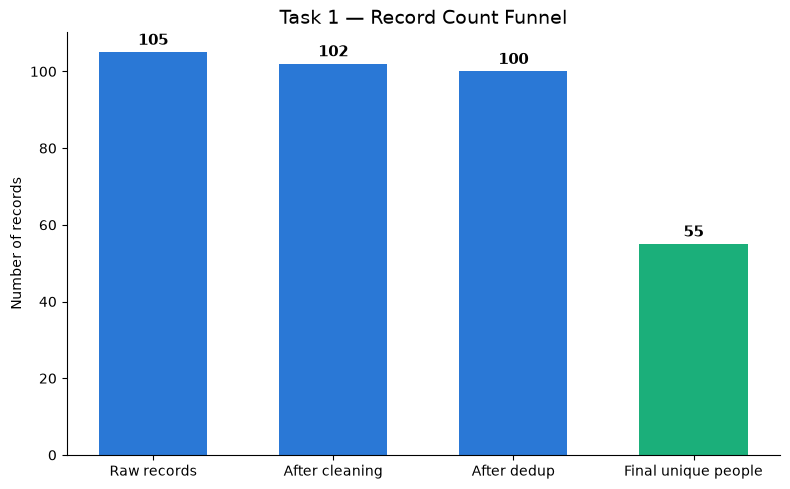

In [26]:
import matplotlib.pyplot as plt

stages = ["Raw records", "After cleaning", "After dedup", "Final unique people"]
counts = [
    len(raw_naukri) + len(raw_gig) + len(raw_cbnexus),
    len(naukri_clean) + len(gig_clean) + len(cbnexus_clean),
    len(naukri_deduped) + len(gig_clean) + len(cbnexus_clean),
    total_people,
]

colors = ["#2a78d6", "#2a78d6", "#2a78d6", "#1baf7a"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(stages, counts, color=colors, width=0.6)

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
             str(count), ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_title("Task 1 — Record Count Funnel", fontsize=14)
ax.set_ylabel("Number of records")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("task1_merge_funnel.png", dpi=150)
plt.show()